# Rāśigata System Framework

## Purpose & Design

This framework enables analysis and visualization of different **Rāśigata computational systems** from [Indian astronomical texts](https://archive.org/details/in.ernet.dli.2015.281145/page/244/mode/2up). Each system (Vidyā Mādhavīyam, Bhāskara II, Brahmagupta, etc.) provides:

- **Bhūtasaṅkhyā** terms encoding nakṣatra-wise angular measurements (amsha)
- **Sanskrit verses** (ślokas) containing the encoded data
- **Rāśi projection algorithms** to derive zodiacal positions from the measurements

### Key Capabilities

1. **Multi-System Support**: Work with different astronomical treatises using a unified interface
2. **Flexible Algorithms**: Choose between cumulative (mathematically rigorous) or dip-based (text-encoded) projection methods
3. **Comparative Analysis**: Side-by-side comparison of different systems and algorithms
4. **Rich Visualizations**: Linear and polar charts with customizable display options
5. **Data Access**: Full access to computed data for custom analysis

### Design Philosophy

The implementation focuses on:
- **Encapsulation**: Each system is self-contained with its data and behavior
- **Flexibility**: System-specific configurations (jitter, projection method, etc.)
- **Extensibility**: Easy to add new systems or projection algorithms
- **Reproducibility**: Lazy-loaded, cached computations for consistency

In [73]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
class RasigataSystem:
    """
    Encapsulates a Rāśigata computational system with its data, processing, and visualization.
    """
    
    # Class-level constants shared across all systems
    NAKSATRA_NAMES = [
        'Aśvinī', 'Bharaṇī', 'Kṛttikā', 'Rohiṇī', 'Mṛgaśīrṣa', 'Ārdrā', 
        'Punarvasu', 'Puṣya', 'Āśleṣā', 'Maghā', 'Pūrvāphālgunī', 
        'Uttarāphālgunī', 'Hasta', 'Citrā', 'Svātī', 'Viśākhā', 'Anurādhā', 
        'Jyeṣṭhā', 'Mūla', 'Pūrvāṣāḍhā', 'Uttarāṣāḍhā', 'Śravaṇa', 
        'Dhaniṣṭhā', 'Śatabhiṣā', 'Pūrvabhādrapadā', 'Uttarabhādrapadā', 'Revatī'
    ]
    
    RASI_NAMES = [
        'Meṣa', 'Vṛṣabha', 'Mithuna', 'Karka', 'Siṃha', 'Kanyā', 
        'Tulā', 'Vṛścika', 'Dhanu', 'Makara', 'Kumbha', 'Mīna'
    ]
    
    RASI_COLOR_MAP = {
        'Meṣa': 'red', 'Vṛṣabha': 'green', 'Mithuna': 'blue', 'Karka': 'darkorange',
        'Siṃha': 'purple', 'Kanyā': 'brown', 'Tulā': 'red', 'Vṛścika': 'darkcyan',
        'Dhanu': 'magenta', 'Makara': 'maroon', 'Kumbha': 'purple', 'Mīna': 'teal'
    }
    
    # Registry of available projection methods
    PROJECTION_METHODS = ['cumulative', 'dip']
    
    def __init__(self, name, author, verse, bhoota, amsha, 
                 polar_jitter_indices=None, projection_method='cumulative'):
        """
        Initialize a Rāśigata system.
        
        Args:
            name: Name of the system
            author: Author/source
            verse: Sanskrit verse (śloka)
            bhoota: List of 27 bhūtasaṅkhyā terms
            amsha: List of 27 amsha values
            polar_jitter_indices: Dict mapping nakṣatra indices to jitter angle (degrees)
                                  e.g., {11: 3, 17: 3, 18: 3} for VM system
            projection_method: 'cumulative' (default) or 'dip'
                              - 'cumulative': Treats each amsha as offset, accumulates degrees
                              - 'dip': Advances rāśi when amsha value drops (legacy)
        """
        self.name = name
        self.author = author
        self.verse = verse
        self.bhoota = bhoota
        self.amsha = amsha
        self.polar_jitter_indices = polar_jitter_indices or {}
        
        if projection_method not in self.PROJECTION_METHODS:
            raise ValueError(f"projection_method must be one of {self.PROJECTION_METHODS}")
        self.projection_method = projection_method
        
        # Computed data (lazy loaded)
        self._base_df = None
        self._processed_df = None
    
    def create_base_table(self):
        """Creates the base DataFrame with Nakṣatra names and Bhutasankhya values."""
        if self._base_df is None:
            naks_data = {
                'naks_num': list(range(1, 28)),
                'naks_name': self.NAKSATRA_NAMES,
                'bhoota': self.bhoota,
                'amsha': self.amsha
            }
            self._base_df = pd.DataFrame(naks_data)
        return self._base_df
    
    def project_rasis_dip(self, df):
        """
        Projects Rāśi based on the 'Simple Dip Theory' (legacy method).
        Rāśi advances whenever amsha value drops.
        """
        result = df.copy()
        
        result['rasi_num'] = 0
        result.loc[0, 'rasi_num'] = 1
        
        current_rasi = 1
        for i in range(1, len(result)):
            if result.loc[i, 'amsha'] < result.loc[i-1, 'amsha']:
                current_rasi += 1
            result.loc[i, 'rasi_num'] = current_rasi
        
        result['rasi_name'] = result['rasi_num'].apply(
            lambda x: self.RASI_NAMES[x-1] if x <= len(self.RASI_NAMES) else f"Rāśi {x}"
        )
        result['long_degrees'] = (result['rasi_num'] - 1) * 30 + result['amsha']
        
        return result
    
    def project_rasis_cumulative(self, df):
        """
        Projects Rāśi based on cumulative offset method (mathematically correct).
        Each amsha is treated as an angular offset that accumulates.
        Rāśi is derived from the cumulative longitude.
        """
        result = df.copy()
        
        # Accumulate amsha values to get cumulative degrees
        result['long_degrees'] = result['amsha'].cumsum()
        
        # Derive rāśi number from cumulative degrees (each rāśi is 30°)
        result['rasi_num'] = (result['long_degrees'] // 30).astype(int) + 1
        
        # Calculate position within the current rāśi
        result['amsha_in_rasi'] = result['long_degrees'] % 30
        
        # Map rāśi number to name
        result['rasi_name'] = result['rasi_num'].apply(
            lambda x: self.RASI_NAMES[x-1] if x <= len(self.RASI_NAMES) else f"Rāśi {x}"
        )
        
        return result
    
    def project_rasis(self, df):
        """
        Dispatcher method that calls the appropriate projection method
        based on self.projection_method.
        """
        if self.projection_method == 'dip':
            return self.project_rasis_dip(df)
        elif self.projection_method == 'cumulative':
            return self.project_rasis_cumulative(df)
        else:
            raise ValueError(f"Unknown projection method: {self.projection_method}")
    
    def process(self):
        """Complete processing pipeline: creates table → projects Rāśis → adds analysis columns."""
        if self._processed_df is None:
            base_df = self.create_base_table()
            projected_df = self.project_rasis(base_df)
            
            self._processed_df = projected_df.assign(
                _amsha_dip=lambda x: x.amsha.diff().fillna(-1).apply(lambda v: 1 if v < 0 else 0),
                _rasi_via_dip=lambda x: x._amsha_dip.cumsum(),
                _amsha_sum=lambda x: x.amsha.cumsum(),
                _rasi_transition=lambda x: (x.rasi_num != x.rasi_num.shift()).astype(int)
            )
        return self._processed_df
    
    def get_data(self):
        """Returns the processed DataFrame."""
        return self.process()
    
    def display_table(self):
        """Display styled table with verse as caption."""
        df = self.get_data()
        
        # Format verse for HTML display
        verse_html = re.sub(r'\n+', '<br>', self.verse.strip())
        
        method_label = "Cumulative Offset" if self.projection_method == 'cumulative' else "Dip Method"
        caption = f"""<h2>{self.name}</h2>
        <p><em>by {self.author}</em></p>
        <p style='font-size: 12px; color: #666;'>Projection Method: <strong>{method_label}</strong></p>
        <div style='font-family: serif; font-size: 14px; margin: 10px 0;'>{verse_html}</div>"""
        
        def highlight_rasi_transition(row):
            """Highlights rows that mark the beginning of a new Rāśi."""
            is_transition_row = row['_rasi_transition'] == 1
            return ['color: #0000ff'] * len(row) if is_transition_row else [''] * len(row)
        
        return df.set_index('naks_num').style.apply(highlight_rasi_transition, axis=1).set_caption(caption)
    
    def plot_linear(self, ax=None):
        """Creates a linear plot showing Rāśi progression."""
        df = self.get_data()
        
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 20))
        
        ax.plot(df['naks_num'], df['long_degrees'], marker='o')
        
        # Label each point with nakṣatra name
        for i, row in df.iterrows():
            ax.text(
                row['naks_num'], row['long_degrees'], 
                f"{(i+1):2d})  {row['long_degrees']:3.0f}°  {row['naks_name']}  ", 
                fontsize=12, ha='right', va='bottom', 
                rotation=-65,
                color=self.RASI_COLOR_MAP.get(row['rasi_name'], 'black')
            )
            
            # Annotate rāśi changes
            if row['_rasi_transition'] == 1:
                label = f"{row['rasi_name']}"
                # Check if label contains a digit
                if any(char.isdigit() for char in label):
                    bbox_props = dict(boxstyle="round,pad=0.3", fc="#ff8888", ec="none", alpha=0.7)
                else:
                    bbox_props = None
                ax.annotate(
                    label, 
                    xy=(row['naks_num'], row['long_degrees']), 
                    xytext=(row['naks_num']+1.5, row['long_degrees']-10),
                    arrowprops=dict(facecolor='black', arrowstyle='->'),
                    fontsize=12, ha='left', va='top',
                    color=self.RASI_COLOR_MAP.get(row['rasi_name'], 'black'),
                    bbox=bbox_props
                )
        
        ax.grid(True)
        method_label = "Cumulative" if self.projection_method == 'cumulative' else "Dip"
        ax.set_title(f"Nakṣatra-wise Rāśi and Polar Longitudes\n{self.name} by {self.author}", #"\n({method_label} Method)", 
                     fontsize=16)
        ax.set_facecolor('#f0f0f0')
        ax.figure.set_facecolor('#f0f0e0')
        
        return ax
    
    def plot_polar(self, ax=None):
        """Creates a polar plot showing Rāśi progression."""
        df = self.get_data()

        if ax is None:
            fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(15, 15))
        
        theta = np.deg2rad(df['long_degrees'])
        r = np.ones_like(theta)
        
        ax.set_theta_direction(-1)  # Set direction to clockwise
        ax.plot(theta, r, 'o', label='Nakṣatra')
        
        for i, row in df.iterrows():
            # Apply system-specific jitter
            jitter = self.polar_jitter_indices.get(i, 0) * np.pi / 180
            
            label = f"{row['naks_name']} ~ °{row['amsha']} {row['bhoota']}"
            color = self.RASI_COLOR_MAP.get(row['rasi_name'], 'black')
            # Highlight with mild red if rasi_num > 12
            if row['rasi_num'] > 12:
                bbox = dict(boxstyle="round,pad=0.3", fc="#ffcccc", ec="none", alpha=0.7)
            else:
                bbox = None
            ax.text(
                np.deg2rad(row['long_degrees']) + jitter, 
                1 + -.08 - len(label)*0.01,
                f"{(i+1):2d}) {label}",
                fontsize=14, 
                ha='center', 
                va='center',
                rotation=-row['long_degrees'] + 0 if ((row['long_degrees'] > 270) or (row['long_degrees'] < 90)) else -row['long_degrees'] - 180,
                color=color,
                bbox=bbox
            )
        
        method_label = "Cumulative" if self.projection_method == 'cumulative' else "Dip"
        caption = f"Nakṣatra-wise Rāśi and Polar Longitudes\n{self.name} by {self.author}\n({method_label} Method)"
        ax.set_title(caption, fontsize=16, pad=20)
        ax.set_yticklabels([])
        ax.set_facecolor('#f0f0f0')
        ax.figure.set_facecolor('#f0f0e0')
        ax.grid(False)
        
        # Add radial grid lines at 30 degree intervals
        ax.set_xticks(np.deg2rad(np.arange(0, 360, 30)))
        ax.xaxis.grid(True, linestyle='--', color='gray', alpha=0.7)
        
        # Label each rāśi at the outer edge
        for rasi, angle in zip(self.RASI_COLOR_MAP.keys(), np.arange(0, 360, 30)):
            _rasi = rasi[::-1] if angle < 180 else rasi
            for ix, c in enumerate(_rasi):
                _angle = np.deg2rad(angle) + 15*np.pi/180 + (ix-len(rasi)//2)*2*np.pi/180
                ax.text(
                    _angle, 1.1, c, 
                    fontsize=14, ha='center', va='center', 
                    color=self.RASI_COLOR_MAP[rasi],
                    rotation=-_angle*180/np.pi + 90 if angle < 180 else -_angle*180/np.pi - 90
                )
        
        return ax
    
    def __repr__(self):
        return f"RasigataSystem('{self.name}' by {self.author}, method={self.projection_method})"


print("✓ RasigataSystem class created with Strategy Pattern for projection methods")
print(f"  Available methods: {RasigataSystem.PROJECTION_METHODS}")
print(f"  Default method: 'cumulative'")

✓ RasigataSystem class created with Strategy Pattern for projection methods
  Available methods: ['cumulative', 'dip']
  Default method: 'cumulative'


In [89]:
# Instantiate the three systems with their specific configurations

vidya_madhaviyam = RasigataSystem(
    name='Vidyā Mādhavīyam',
    author='Mādhava',
    verse="""वस्वृक्षाङ्गपुराणलोचनदिशो वेदांस्तिथिं सङ्गतिं
विद्येध्माब्धिविकृत्यनुष्णकिरणात्यष्टयाकृतीन् भास्करान्।
विद्येन्द्विन्द्रभभूमिपोत्कृतिगिरीन् भांशान् दशोपान्तिमां
(-स्तीर्त्यांशानुदयन्ति भानि परतो भागैः क्रियादेः क्रमात्)॥""",
    bhoota=[
        'vasu', 'ṛkṣa', 'aṅga', 'purāṇa', 'locana', 'diśa', 'veda', 'tithi',
        'saṅgati', 'vidyā', 'idhma', 'abdhi', 'vikṛti', 'anuṣṇakiraṇa',
        'atyaṣṭi', 'ākṛti', 'bhāskara', 'vidyā', 'indu', 'indra', 'bha',
        'bhūmipa', 'utkṛti', 'giri', 'bhāṃśa', 'daśa', 'upāntima'
    ],
    amsha=[
        8, 27, 6, 18, 2, 10, 4, 15, 20, 14, 3, 4, 23, 1, 17, 22, 12, 14,
        1, 14, 27, 16, 26, 7, 12, 10, 26
    ],
    polar_jitter_indices={11: 3, 13: 3, 17: 3, 18: 5, 3:-3}  # VM-specific jitter
)

bhaskara = RasigataSystem(
    name='Bhāskara II',
    author='Bhāskarācārya',
    verse="""अष्टावष्टादश दिशो मनवोऽर्का द्वयोर्धनाः ।
द्वाविंशतिश्व विश्वे च नवशक्रास्त्रयोदश ॥
दिशो विंशतिरेकोना द्वादशार्कास्त्रिपञ्चकम् ।
दिशो रसाश्च विश्वे च विश्वे सूर्या धृतिस्तथा ।।
रुद्रास्सूर्यास्त्रिसप्ताथ शैलेन्दुतिथयः क्रमात् ।
पूर्वपूर्वयुता ज्ञेया योगभागा यथोदिताः ॥
आप्यवैष्णवमूलानां पितृवासध्योरपि ।
त्रिंशल्लिप्तास्सयाम्यानां क्षेप्या वैश्वस्य शेषतः ।।
योगभागसमः सर्वः संयुक्तो लक्ष्यते गृहम् ।
अधिकोनकलाकालविज्ञानं चानुपाततः ॥""",
    bhoota=[
        'aṣṭau', 'aṣṭādaśa', 'diśa', 'manavaḥ', 'arkā', 'dvayordhanāḥ',
        'dvāviṃśatiḥ', 'viśve', 'nava', 'śakrāḥ', 'trayodaśa', 'diśa',
        'viṃśatirekonā', 'dvādaśārkāḥ', 'tripañcakam', 'diśa', 'rasāḥ',
        'viśve', 'viśve', 'sūryā', 'dhṛtiḥ', 'rudrāḥ', 'sūryāḥ',
        'trisapta', 'śaila', 'indu', 'tithayaḥ'
    ],
    amsha=[
        8, 18, 10, 14, 12, 20, 22, 13, 9, 14, 13, 10, 19, 12, 15, 10, 6,
        13, 13, 12, 18, 11, 12, 21, 7, 1, 15
    ],
    polar_jitter_indices={2: 5, 8: 4, 19: 3, 25:3}  # Bhāskara-specific jitter

)

brahmagupta = RasigataSystem(
    name='Brahmagupta / Sūrya Siddhānta',
    author='Brahmagupta / Paraṃparā',
    verse="""अष्टनवैर्मेषे गवि रदलिप्तोनैर्गुणस्स्वरौर्मथुने ।
कर्कटके गुणषोडशधृतिभिः सिंहे नवत्रिधनैः ॥
कन्यायां पञ्चनखैः तुलिनि त्रयतिधृतिभिरळिनि ।
सेषुकलैः त्रिधृतिर्धनुषि शशाङ्कमनुनवतत्वैः ॥
मकरेऽष्टनखैः कुम्भे नवषाशैर्झषे मुनित्रिंशैः ।
पृथगश्विन्यादीनां ध्रुवकांशैर्योगताराः स्वैः ॥""",
    bhoota = [
        'aṣṭa', 'nava',         # For Meṣa
        'radaliptona', 'guṇa', 'svara', # For Vṛṣabha & Mithuna
        'guṇa', 'ṣoḍaśa', 'dhṛti',# For Karkaṭaka
        'nava', 'trighana',          # For Siṃha
        'pañca', 'nakha',        # For Kanyā
        'traya', 'atidhṛti',   # For Tulā
        'iṣu', 'kala',                 # For Vṛścika
        'tri', 'dhṛti',  'śaśanka' , 'manu', 'nava',       # For Dhanuṣa
        'aṣṭa', 'nakha',        # For Makara
        'nava', 'ṣaḍ',          # For Kumbha
        'muni', 'triṃśat'     # For Mīna
    ],
    amsha=[
        8,  9, 31,  3, 7,  3, 16, 18,  9, 
        27, 5, 20,  3, 19, 5, 16,  3, 18,
        1, 14, 9, 8, 20, 9, 26, 7, 30,
    ],
    polar_jitter_indices={
        2: 3,   # Kṛttikā 
        10: 3,  # Maghā  
        22: 3   # Śravaṇa
    }
)

xbrahmagupta = RasigataSystem(
    name='Brahmagupta',
    author='Brahmagupta',
    verse="""अष्टाब्धिदन्तैकपदञ्च सप्त...॥""",
    bhoota=[
        'aṣṭa', 'abdhi', 'danta', 'eka', 'pada', 'sapta', 'candra', 'tri',
        'pañca', 'nava', 'śūnya', 'dva', 'aṣṭa', 'pañca', 'ṣaṭ', 'abdhi',
        'nava', 'saptaka', 'eka', 'catur', 'pañca', 'ṣaṭ', 'tri', 'dva',
        'aṣṭa', 'nava', 'daśa'
    ],
    amsha=[
        8, 4, 32, 1, 4, 7, 1, 3, 5, 9, 
        0, 2,  8, 5, 6, 4, 9, 7, 1, 4, 
        5, 6,  3, 2, 8, 9, 10
    ],
    polar_jitter_indices={2: 6, 10: 4}  # Brahmagupta-specific jitter
)

# Store in a registry for easy iteration
SYSTEMS_REGISTRY = {
    'vidya_madhaviyam': vidya_madhaviyam,
    'bhaskara': bhaskara,
    'brahmagupta': brahmagupta,
}

print("✓ Created system instances:")
for key, system in SYSTEMS_REGISTRY.items():
    print(f"  - {key}: {system}")

✓ Created system instances:
  - vidya_madhaviyam: RasigataSystem('Vidyā Mādhavīyam' by Mādhava, method=cumulative)
  - bhaskara: RasigataSystem('Bhāskara II' by Bhāskarācārya, method=cumulative)
  - brahmagupta: RasigataSystem('Brahmagupta / Sūrya Siddhānta' by Brahmagupta / Paraṃparā, method=cumulative)


### Projection Method Comparison

The class now supports two projection methods:

**Cumulative Method (Default)**: 
- Treats each amsha as an angular offset
- Accumulates degrees: `long_degrees = cumsum(amsha)`
- Derives rāśi from accumulated longitude: `rasi = floor(long_degrees / 30) + 1`
- Mathematically correct for continuous angular measurements

**Dip Method (Legacy)**:
- Advances rāśi whenever `amsha[i] < amsha[i-1]`
- Useful when data explicitly encodes boundaries via value drops
- Preserved for backward compatibility and specific use cases

In [90]:
# Create comparison: same system with different projection methods
vm_cumulative = vidya_madhaviyam  # Already using cumulative (default)
bhaskara_cumulative = bhaskara
brahmagupta_cumulative = brahmagupta

vm_dip = RasigataSystem(
    name='Vidyā Mādhavīyam',
    author='Mādhava',
    verse=vidya_madhaviyam.verse,
    bhoota=vidya_madhaviyam.bhoota,
    amsha=vidya_madhaviyam.amsha,
    polar_jitter_indices=vidya_madhaviyam.polar_jitter_indices,
    projection_method='dip'  # Use legacy dip method
)

bhaskara_dip = RasigataSystem(
    name='Bhāskara II',
    author='Bhāskarācārya',
    verse=bhaskara.verse,
    bhoota=bhaskara.bhoota,
    amsha=bhaskara.amsha,
    # polar_jitter_indices=bhaskara.polar_jitter_indices,
    polar_jitter_indices={0:3, 2: 1, 3:1, 26:3,  6:2,  8: -1, 18:4 , 19: -3, 21:2, 22:-4,  24:-2, 26:4},  # Bhāskara-specific jitter
    projection_method='dip'
)

brahmagupta_dip = RasigataSystem(
    name='Brahmagupta / Sūrya Siddhānta',
    author='Brahmagupta / Paraṃparā',
    verse=brahmagupta.verse,
    bhoota=brahmagupta.bhoota,
    amsha=brahmagupta.amsha,
    polar_jitter_indices=brahmagupta.polar_jitter_indices,
    projection_method='dip'
)

print("✓ Created two versions of Vidyā Mādhavīyam for comparison:")
print(f"  - vm_cumulative: {vm_cumulative}")
print(f"  - vm_dip: {vm_dip}")

print("✓ Created two versions of Bhāskara II for comparison:")
print(f"  - bhaskara_cumulative: {bhaskara_cumulative}")
print(f"  - bhaskara_dip: {bhaskara_dip}")

print("✓ Created two versions of Brahmagupta / Sūrya Siddhānta for comparison:")
print(f"  - brahmagupta: {brahmagupta}")
print(f"  - brahmagupta_dip: {brahmagupta_dip}")

✓ Created two versions of Vidyā Mādhavīyam for comparison:
  - vm_cumulative: RasigataSystem('Vidyā Mādhavīyam' by Mādhava, method=cumulative)
  - vm_dip: RasigataSystem('Vidyā Mādhavīyam' by Mādhava, method=dip)
✓ Created two versions of Bhāskara II for comparison:
  - bhaskara_cumulative: RasigataSystem('Bhāskara II' by Bhāskarācārya, method=cumulative)
  - bhaskara_dip: RasigataSystem('Bhāskara II' by Bhāskarācārya, method=dip)
✓ Created two versions of Brahmagupta / Sūrya Siddhānta for comparison:
  - brahmagupta: RasigataSystem('Brahmagupta / Sūrya Siddhānta' by Brahmagupta / Paraṃparā, method=cumulative)
  - brahmagupta_dip: RasigataSystem('Brahmagupta / Sūrya Siddhānta' by Brahmagupta / Paraṃparā, method=dip)


In [91]:
print("CUMULATIVE METHOD (Default)")
print("=" * 80)
display(vm_cumulative.display_table())
print("=" * 80)
display(bhaskara_cumulative.display_table())
print("=" * 80)
display(brahmagupta_cumulative.display_table())

print("DIP METHOD (Legacy)")
print("=" * 80)
display(vm_dip.display_table())
print("=" * 80)
display(bhaskara_dip.display_table())
print("=" * 80)
display(brahmagupta_dip.display_table())



CUMULATIVE METHOD (Default)


,naks_name,bhoota,amsha,long_degrees,rasi_num,amsha_in_rasi,rasi_name,_amsha_dip,_rasi_via_dip,_amsha_sum,_rasi_transition
naks_num,,,,,,,,,,,
1,Aśvinī,vasu,8,8,1,8,Meṣa,1,1,8,1
2,Bharaṇī,ṛkṣa,27,35,2,5,Vṛṣabha,0,1,35,1
3,Kṛttikā,aṅga,6,41,2,11,Vṛṣabha,1,2,41,0
4,Rohiṇī,purāṇa,18,59,2,29,Vṛṣabha,0,2,59,0
5,Mṛgaśīrṣa,locana,2,61,3,1,Mithuna,1,3,61,1
6,Ārdrā,diśa,10,71,3,11,Mithuna,0,3,71,0
7,Punarvasu,veda,4,75,3,15,Mithuna,1,4,75,0
8,Puṣya,tithi,15,90,4,0,Karka,0,4,90,1
9,Āśleṣā,saṅgati,20,110,4,20,Karka,0,4,110,0


,naks_name,bhoota,amsha,long_degrees,rasi_num,amsha_in_rasi,rasi_name,_amsha_dip,_rasi_via_dip,_amsha_sum,_rasi_transition
naks_num,,,,,,,,,,,
1,Aśvinī,aṣṭau,8,8,1,8,Meṣa,1,1,8,1
2,Bharaṇī,aṣṭādaśa,18,26,1,26,Meṣa,0,1,26,0
3,Kṛttikā,diśa,10,36,2,6,Vṛṣabha,1,2,36,1
4,Rohiṇī,manavaḥ,14,50,2,20,Vṛṣabha,0,2,50,0
5,Mṛgaśīrṣa,arkā,12,62,3,2,Mithuna,1,3,62,1
6,Ārdrā,dvayordhanāḥ,20,82,3,22,Mithuna,0,3,82,0
7,Punarvasu,dvāviṃśatiḥ,22,104,4,14,Karka,0,3,104,1
8,Puṣya,viśve,13,117,4,27,Karka,1,4,117,0
9,Āśleṣā,nava,9,126,5,6,Siṃha,1,5,126,1


,naks_name,bhoota,amsha,long_degrees,rasi_num,amsha_in_rasi,rasi_name,_amsha_dip,_rasi_via_dip,_amsha_sum,_rasi_transition
naks_num,,,,,,,,,,,
1,Aśvinī,aṣṭa,8,8,1,8,Meṣa,1,1,8,1
2,Bharaṇī,nava,9,17,1,17,Meṣa,0,1,17,0
3,Kṛttikā,radaliptona,31,48,2,18,Vṛṣabha,0,1,48,1
4,Rohiṇī,guṇa,3,51,2,21,Vṛṣabha,1,2,51,0
5,Mṛgaśīrṣa,svara,7,58,2,28,Vṛṣabha,0,2,58,0
6,Ārdrā,guṇa,3,61,3,1,Mithuna,1,3,61,1
7,Punarvasu,ṣoḍaśa,16,77,3,17,Mithuna,0,3,77,0
8,Puṣya,dhṛti,18,95,4,5,Karka,0,3,95,1
9,Āśleṣā,nava,9,104,4,14,Karka,1,4,104,0


DIP METHOD (Legacy)


,naks_name,bhoota,amsha,rasi_num,rasi_name,long_degrees,_amsha_dip,_rasi_via_dip,_amsha_sum,_rasi_transition
naks_num,,,,,,,,,,
1,Aśvinī,vasu,8,1,Meṣa,8,1,1,8,1
2,Bharaṇī,ṛkṣa,27,1,Meṣa,27,0,1,35,0
3,Kṛttikā,aṅga,6,2,Vṛṣabha,36,1,2,41,1
4,Rohiṇī,purāṇa,18,2,Vṛṣabha,48,0,2,59,0
5,Mṛgaśīrṣa,locana,2,3,Mithuna,62,1,3,61,1
6,Ārdrā,diśa,10,3,Mithuna,70,0,3,71,0
7,Punarvasu,veda,4,4,Karka,94,1,4,75,1
8,Puṣya,tithi,15,4,Karka,105,0,4,90,0
9,Āśleṣā,saṅgati,20,4,Karka,110,0,4,110,0


,naks_name,bhoota,amsha,rasi_num,rasi_name,long_degrees,_amsha_dip,_rasi_via_dip,_amsha_sum,_rasi_transition
naks_num,,,,,,,,,,
1,Aśvinī,aṣṭau,8,1,Meṣa,8,1,1,8,1
2,Bharaṇī,aṣṭādaśa,18,1,Meṣa,18,0,1,26,0
3,Kṛttikā,diśa,10,2,Vṛṣabha,40,1,2,36,1
4,Rohiṇī,manavaḥ,14,2,Vṛṣabha,44,0,2,50,0
5,Mṛgaśīrṣa,arkā,12,3,Mithuna,72,1,3,62,1
6,Ārdrā,dvayordhanāḥ,20,3,Mithuna,80,0,3,82,0
7,Punarvasu,dvāviṃśatiḥ,22,3,Mithuna,82,0,3,104,0
8,Puṣya,viśve,13,4,Karka,103,1,4,117,1
9,Āśleṣā,nava,9,5,Siṃha,129,1,5,126,1


,naks_name,bhoota,amsha,rasi_num,rasi_name,long_degrees,_amsha_dip,_rasi_via_dip,_amsha_sum,_rasi_transition
naks_num,,,,,,,,,,
1,Aśvinī,aṣṭa,8,1,Meṣa,8,1,1,8,1
2,Bharaṇī,nava,9,1,Meṣa,9,0,1,17,0
3,Kṛttikā,radaliptona,31,1,Meṣa,31,0,1,48,0
4,Rohiṇī,guṇa,3,2,Vṛṣabha,33,1,2,51,1
5,Mṛgaśīrṣa,svara,7,2,Vṛṣabha,37,0,2,58,0
6,Ārdrā,guṇa,3,3,Mithuna,63,1,3,61,1
7,Punarvasu,ṣoḍaśa,16,3,Mithuna,76,0,3,77,0
8,Puṣya,dhṛti,18,3,Mithuna,78,0,3,95,0
9,Āśleṣā,nava,9,4,Karka,99,1,4,104,1


In [77]:
def compare_rasigata_charts(system1, system2, tag1='System 1', tag2='System 2'):
    """
    Plot side-by-side linear and polar charts comparing two RasigataSystem objects.
    
    Args:
        system1: First RasigataSystem instance
        system2: Second RasigataSystem instance
        tag1: Label for first system/method
        tag2: Label for second system/method
    """
    # Linear charts
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    system1.plot_linear(ax=axes[0])
    axes[0].set_title(f"{tag1}", fontsize=16, weight='bold')
    system2.plot_linear(ax=axes[1])
    axes[1].set_title(f"{tag2}", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Polar charts
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(20, 10))
    system1.plot_polar(ax=axes[0])
    axes[0].set_title(f"{tag1}", fontsize=16, weight='bold', pad=30)
    system2.plot_polar(ax=axes[1])
    axes[1].set_title(f"{tag2}", fontsize=16, weight='bold', pad=30)
    plt.tight_layout()
    plt.show()


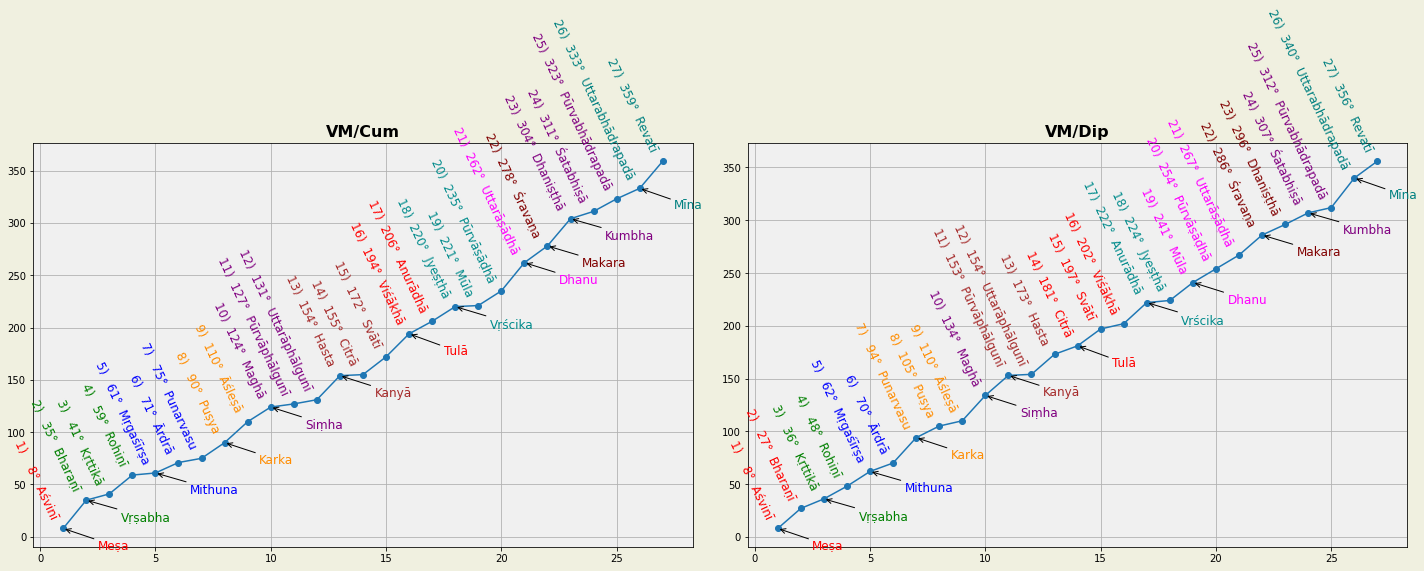

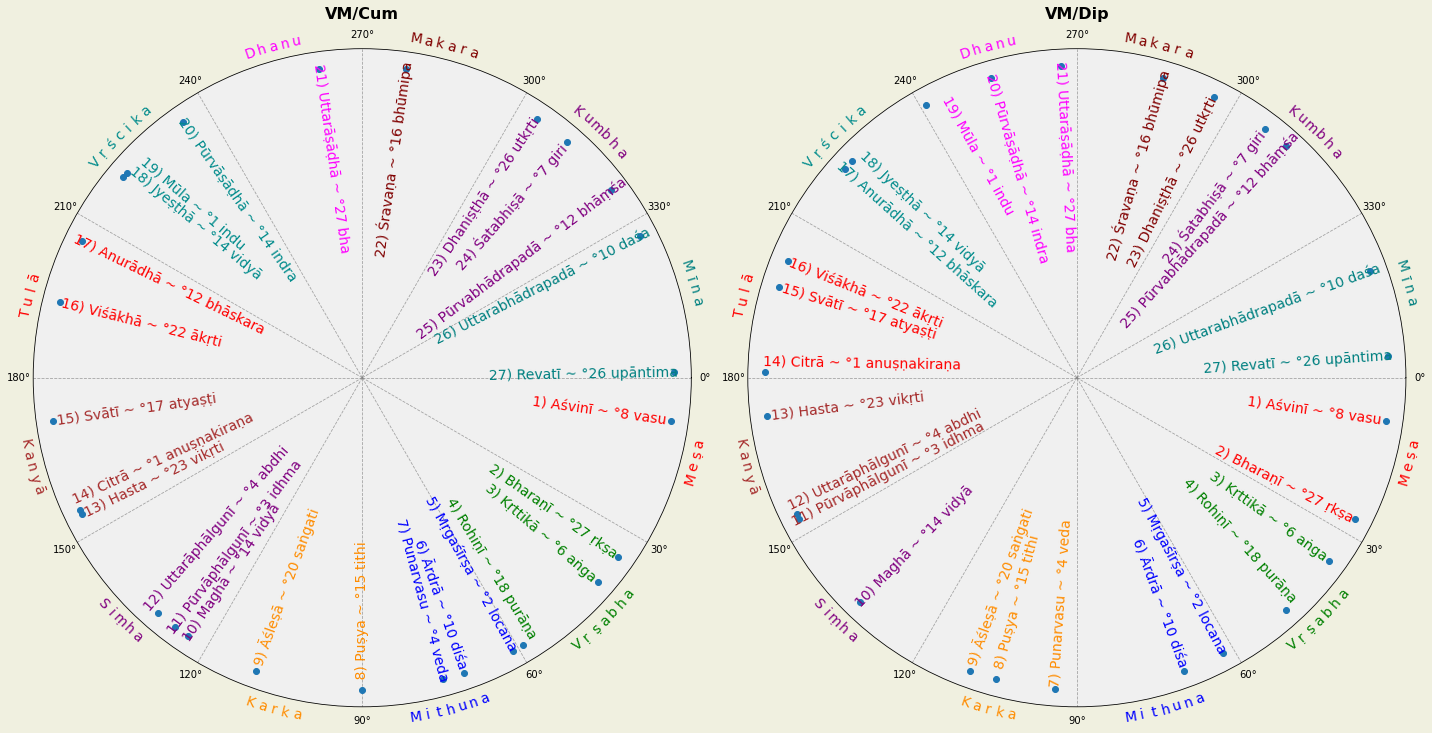

COMPARISON: VM/Cum vs VM/Dip

Total nakṣatras with matching Rāśi: 17 / 27
Average longitude difference: 11.19°
Max longitude difference: 26.00°

Rows where methods differ:
      Nakṣatra  Amsha VM/Cum_Rāśi  VM/Cum_Long VM/Dip_Rāśi  VM/Dip_Long  Rāśi_Match  Long_Diff
       Bharaṇī     27     Vṛṣabha           35        Meṣa           27       False          8
     Punarvasu      4     Mithuna           75       Karka           94       False        -19
 Pūrvāphālgunī      3       Siṃha          127       Kanyā          153       False        -26
Uttarāphālgunī      4       Siṃha          131       Kanyā          154       False        -23
         Citrā      1       Kanyā          155        Tulā          181       False        -26
         Svātī     17       Kanyā          172        Tulā          197       False        -25
      Anurādhā     12        Tulā          206     Vṛścika          222       False        -16
          Mūla      1     Vṛścika          221       Dhanu          

,Nakṣatra,Amsha,VM/Cum_Rāśi,VM/Cum_Long,VM/Dip_Rāśi,VM/Dip_Long,Rāśi_Match,Long_Diff
0,Aśvinī,8,Meṣa,8,Meṣa,8,True,0
1,Bharaṇī,27,Vṛṣabha,35,Meṣa,27,False,8
2,Kṛttikā,6,Vṛṣabha,41,Vṛṣabha,36,True,5
3,Rohiṇī,18,Vṛṣabha,59,Vṛṣabha,48,True,11
4,Mṛgaśīrṣa,2,Mithuna,61,Mithuna,62,True,-1
5,Ārdrā,10,Mithuna,71,Mithuna,70,True,1
6,Punarvasu,4,Mithuna,75,Karka,94,False,-19
7,Puṣya,15,Karka,90,Karka,105,True,-15
8,Āśleṣā,20,Karka,110,Karka,110,True,0
9,Maghā,14,Siṃha,124,Siṃha,134,True,-10


In [78]:
from IPython.display import display, HTML

def compare_rasigata_methods(df1, df2, tag1='Method1', tag2='Method2'):
    """
    Compare two nakṣatra-wise DataFrames and print a detailed report.
    
    Args:
        df1: First DataFrame (must have columns: naks_name, amsha, rasi_name, long_degrees)
        df2: Second DataFrame (same columns as above)
        tag1: Label for first method/system
        tag2: Label for second method/system
    Returns:
        comparison_df: DataFrame with comparison columns
    """
    comparison_df = pd.DataFrame({
        'Nakṣatra': df1['naks_name'],
        'Amsha': df1['amsha'],
        f'{tag1}_Rāśi': df1['rasi_name'],
        f'{tag1}_Long': df1['long_degrees'].round(1),
        f'{tag2}_Rāśi': df2['rasi_name'],
        f'{tag2}_Long': df2['long_degrees'].round(1),
        'Rāśi_Match': df1['rasi_name'] == df2['rasi_name'],
        'Long_Diff': (df1['long_degrees'] - df2['long_degrees']).round(1)
    })

    print(f"COMPARISON: {tag1} vs {tag2}")
    print("=" * 100)
    print(f"\nTotal nakṣatras with matching Rāśi: {comparison_df['Rāśi_Match'].sum()} / {len(comparison_df)}")
    print(f"Average longitude difference: {comparison_df['Long_Diff'].abs().mean():.2f}°")
    print(f"Max longitude difference: {comparison_df['Long_Diff'].abs().max():.2f}°\n")
    print("Rows where methods differ:")
    print(comparison_df[~comparison_df['Rāśi_Match']].to_string(index=False))

    return comparison_df


def compare_rasigata( df1, df2, tag1, tag2, caption) :
    def highlight_rasi_mismatch(row):
        return ['background-color: #ffcccc' if not row['Rāśi_Match'] else '' for _ in row]

    if caption:
        display(HTML(f"<h2>{caption}</h2>"))
    compare_rasigata_charts( df1, df2, tag1, tag2)
    display(compare_rasigata_methods(
        df1.get_data()[['naks_name', 'amsha', 'rasi_name', 'long_degrees']],
        df2.get_data()[['naks_name', 'amsha', 'rasi_name', 'long_degrees']],
        tag1,tag2
    ).style.apply(highlight_rasi_mismatch, axis=1))

compare_rasigata( vm_cumulative, vm_dip, tag1="VM/Cum", tag2="VM/Dip", caption="Comparing Rasi Projections - Vidyaa Maadhaviiyam - Cumulative vs Dip methods")


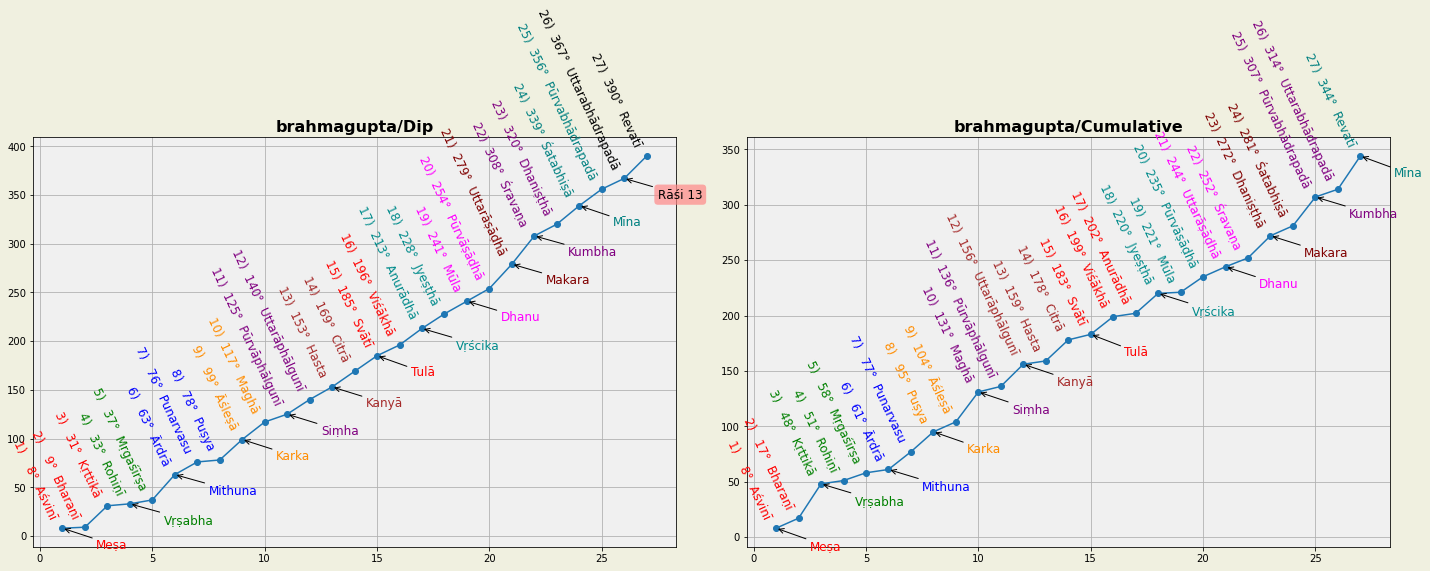

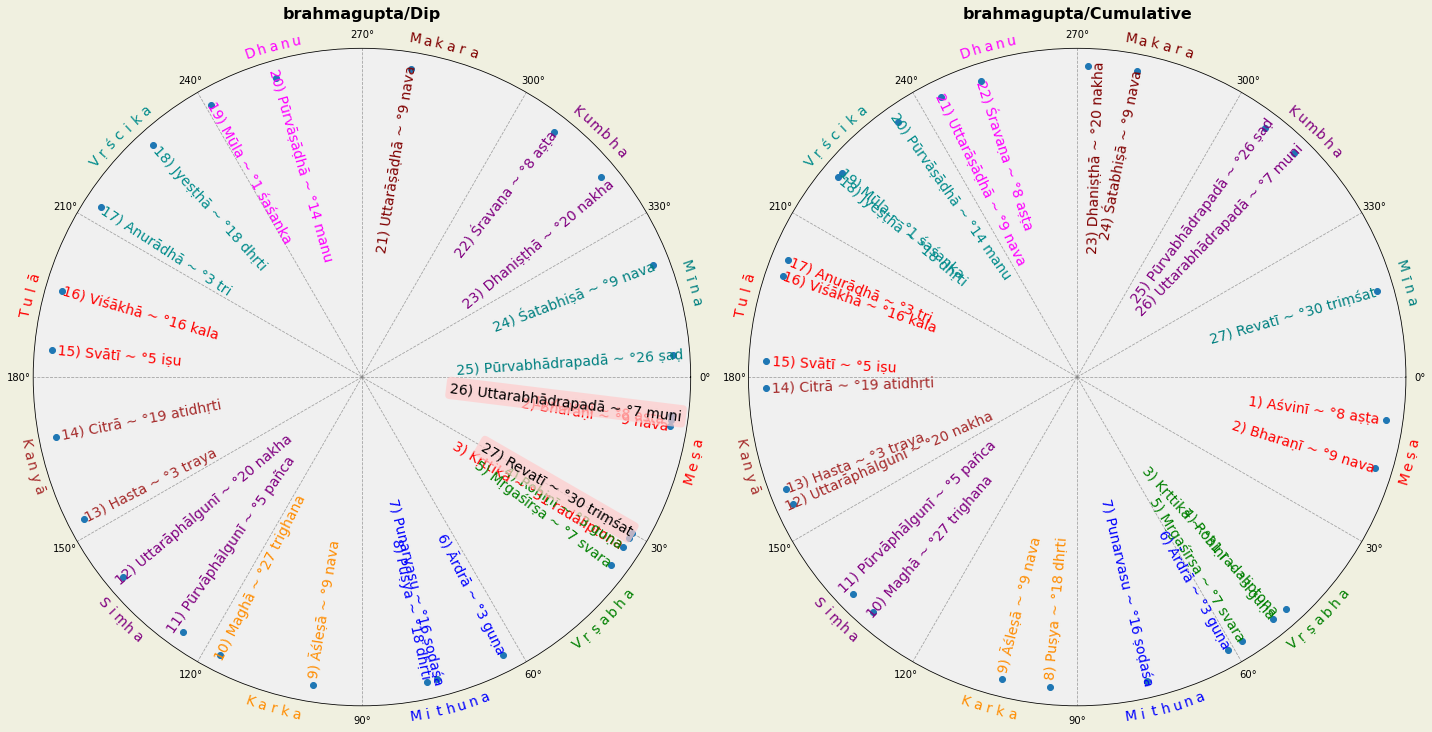

COMPARISON: brahmagupta/Dip vs brahmagupta/Cumulative

Total nakṣatras with matching Rāśi: 13 / 27
Average longitude difference: 20.48°
Max longitude difference: 58.00°

Rows where methods differ:
        Nakṣatra  Amsha brahmagupta/Dip_Rāśi  brahmagupta/Dip_Long brahmagupta/Cumulative_Rāśi  brahmagupta/Cumulative_Long  Rāśi_Match  Long_Diff
         Kṛttikā     31                 Meṣa                    31                     Vṛṣabha                           48       False        -17
           Puṣya     18              Mithuna                    78                       Karka                           95       False        -17
           Maghā     27                Karka                   117                       Siṃha                          131       False        -14
  Uttarāphālgunī     20                Siṃha                   140                       Kanyā                          156       False        -16
        Anurādhā      3              Vṛścika                   213  

,Nakṣatra,Amsha,brahmagupta/Dip_Rāśi,brahmagupta/Dip_Long,brahmagupta/Cumulative_Rāśi,brahmagupta/Cumulative_Long,Rāśi_Match,Long_Diff
0,Aśvinī,8,Meṣa,8,Meṣa,8,True,0
1,Bharaṇī,9,Meṣa,9,Meṣa,17,True,-8
2,Kṛttikā,31,Meṣa,31,Vṛṣabha,48,False,-17
3,Rohiṇī,3,Vṛṣabha,33,Vṛṣabha,51,True,-18
4,Mṛgaśīrṣa,7,Vṛṣabha,37,Vṛṣabha,58,True,-21
5,Ārdrā,3,Mithuna,63,Mithuna,61,True,2
6,Punarvasu,16,Mithuna,76,Mithuna,77,True,-1
7,Puṣya,18,Mithuna,78,Karka,95,False,-17
8,Āśleṣā,9,Karka,99,Karka,104,True,-5
9,Maghā,27,Karka,117,Siṃha,131,False,-14


In [93]:
compare_rasigata(
    brahmagupta_dip,
    brahmagupta_cumulative,
    tag1='brahmagupta/Dip', tag2='brahmagupta/Cumulative',
    caption="Comparing Rasi Projections - Brahmagupta"
)

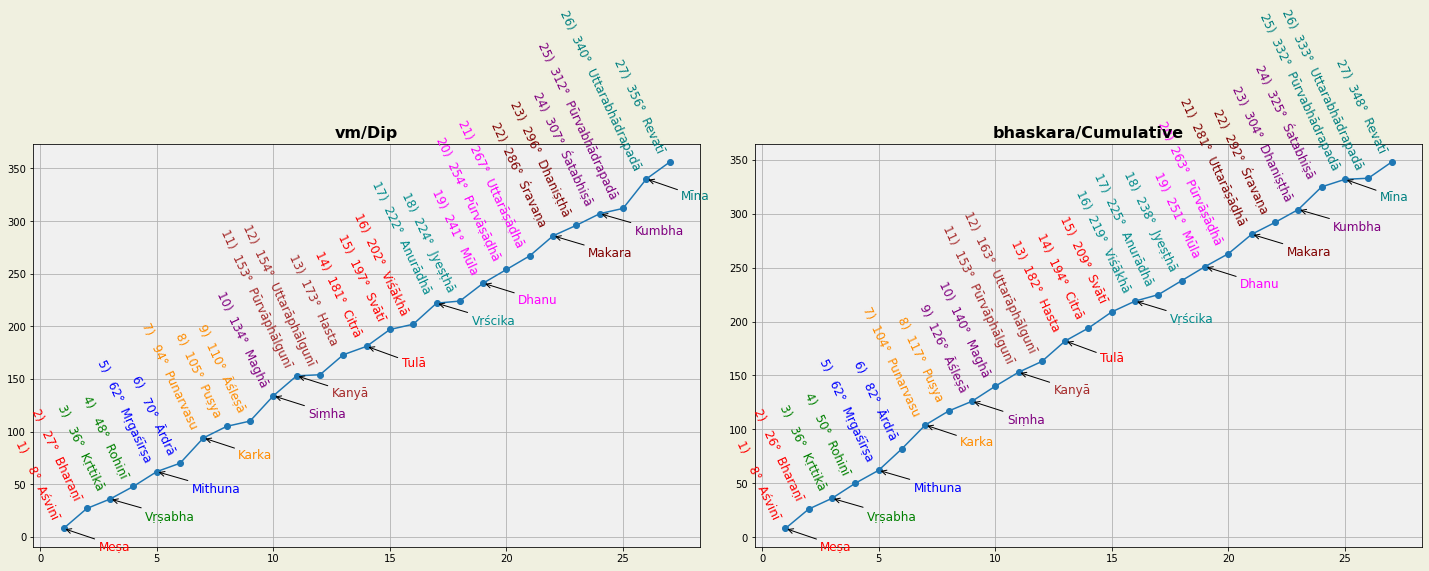

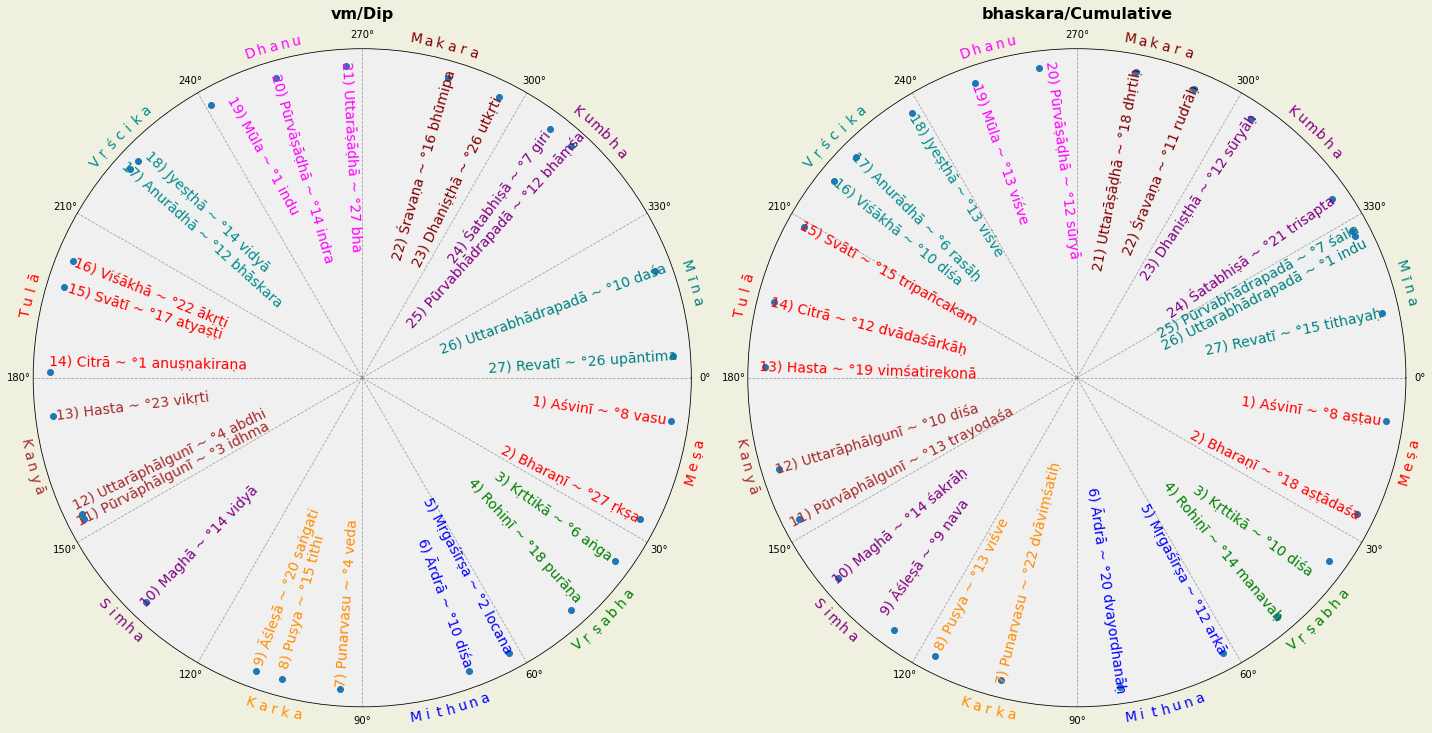

COMPARISON: vm/Dip vs bhaskara/Cumulative

Total nakṣatras with matching Rāśi: 21 / 27
Average longitude difference: 8.74°
Max longitude difference: 20.00°

Rows where methods differ:
       Nakṣatra  Amsha vm/Dip_Rāśi  vm/Dip_Long bhaskara/Cumulative_Rāśi  bhaskara/Cumulative_Long  Rāśi_Match  Long_Diff
         Āśleṣā     20       Karka          110                    Siṃha                       126       False        -16
          Hasta     23       Kanyā          173                     Tulā                       182       False         -9
        Viśākhā     22        Tulā          202                  Vṛścika                       219       False        -17
    Uttarāṣāḍhā     27       Dhanu          267                   Makara                       281       False        -14
      Dhaniṣṭhā     26      Makara          296                   Kumbha                       304       False         -8
Pūrvabhādrapadā     12      Kumbha          312                     Mīna            

,Nakṣatra,Amsha,vm/Dip_Rāśi,vm/Dip_Long,bhaskara/Cumulative_Rāśi,bhaskara/Cumulative_Long,Rāśi_Match,Long_Diff
0,Aśvinī,8,Meṣa,8,Meṣa,8,True,0
1,Bharaṇī,27,Meṣa,27,Meṣa,26,True,1
2,Kṛttikā,6,Vṛṣabha,36,Vṛṣabha,36,True,0
3,Rohiṇī,18,Vṛṣabha,48,Vṛṣabha,50,True,-2
4,Mṛgaśīrṣa,2,Mithuna,62,Mithuna,62,True,0
5,Ārdrā,10,Mithuna,70,Mithuna,82,True,-12
6,Punarvasu,4,Karka,94,Karka,104,True,-10
7,Puṣya,15,Karka,105,Karka,117,True,-12
8,Āśleṣā,20,Karka,110,Siṃha,126,False,-16
9,Maghā,14,Siṃha,134,Siṃha,140,True,-6


In [80]:
compare_rasigata(
    vm_dip,
    bhaskara_cumulative,
    tag1='vm/Dip', tag2='bhaskara/Cumulative',
    caption="Compare Rasi projection - vm/Dip Vs bhaskara/Cumulative"
)

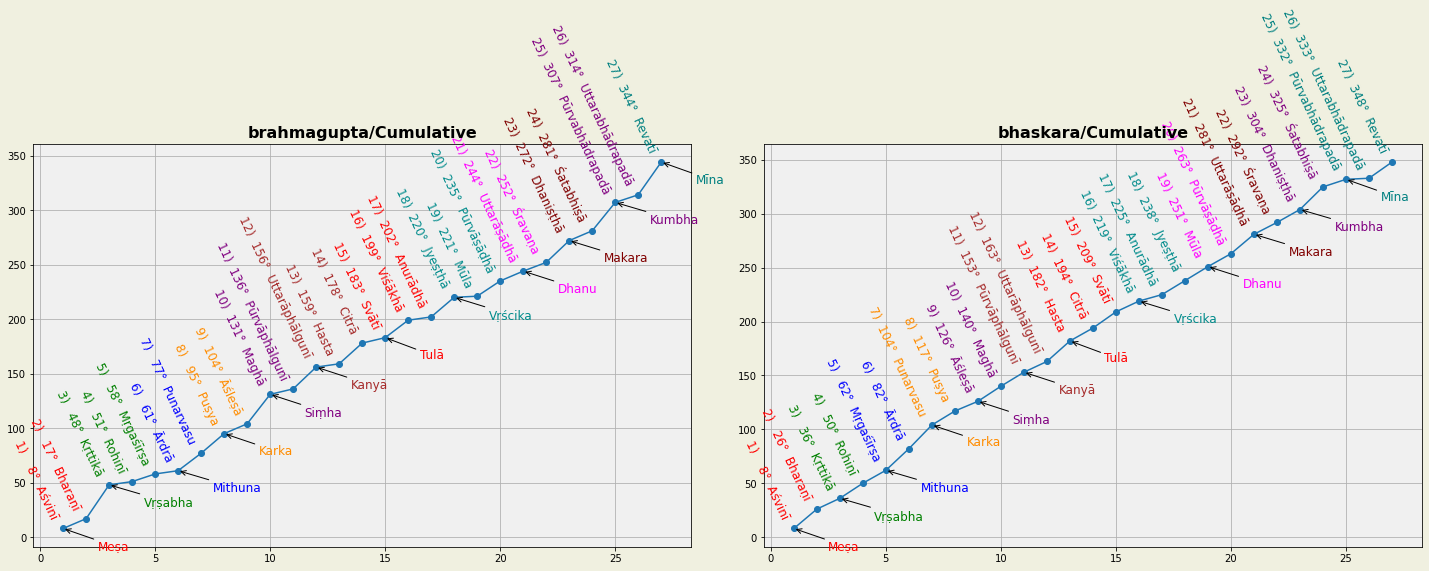

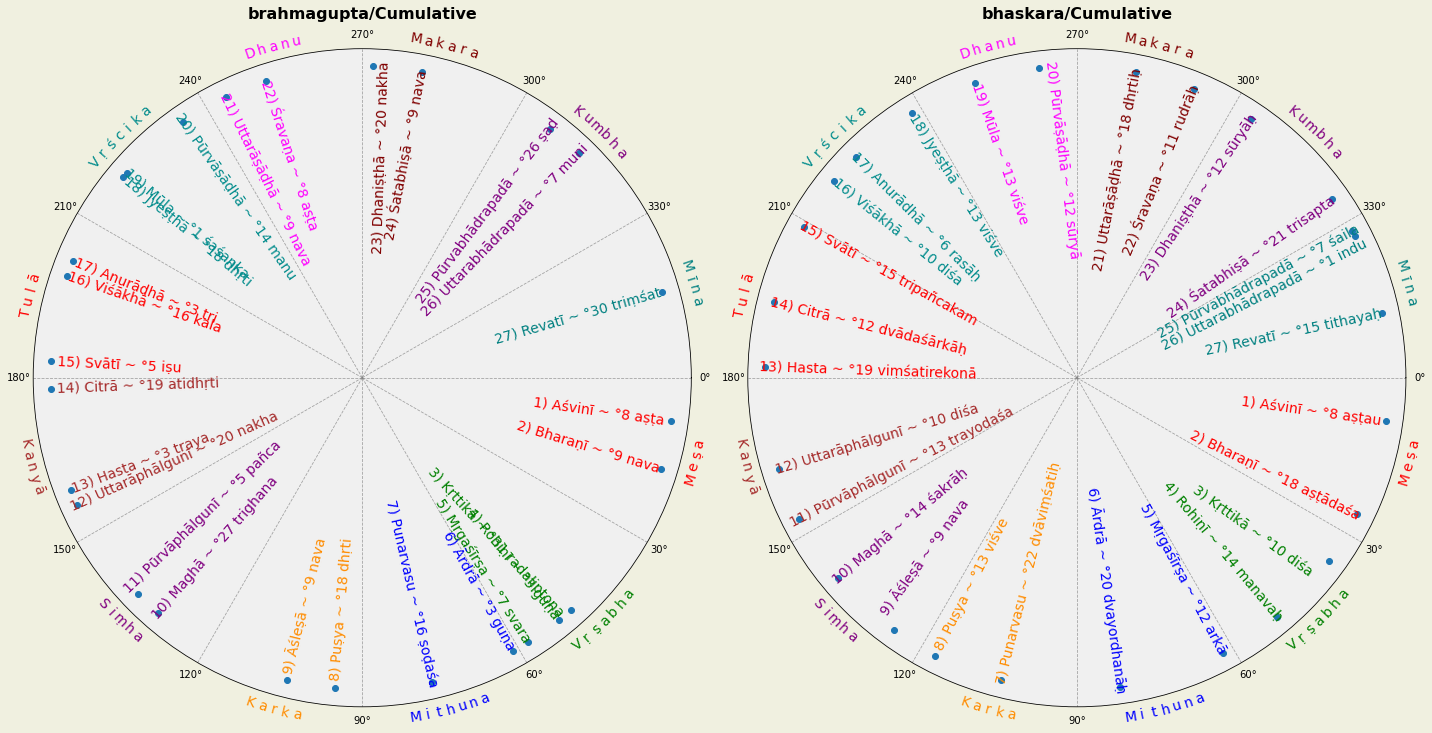

COMPARISON: brahmagupta/Cumulative vs bhaskara/Cumulative

Total nakṣatras with matching Rāśi: 11 / 27
Average longitude difference: 19.85°
Max longitude difference: 44.00°

Rows where methods differ:
        Nakṣatra  Amsha brahmagupta/Cumulative_Rāśi  brahmagupta/Cumulative_Long bhaskara/Cumulative_Rāśi  bhaskara/Cumulative_Long  Rāśi_Match  Long_Diff
       Mṛgaśīrṣa      7                     Vṛṣabha                           58                  Mithuna                        62       False         -4
       Punarvasu     16                     Mithuna                           77                    Karka                       104       False        -27
          Āśleṣā      9                       Karka                          104                    Siṃha                       126       False        -22
   Pūrvāphālgunī      5                       Siṃha                          136                    Kanyā                       153       False        -17
           Hasta      3 

,Nakṣatra,Amsha,brahmagupta/Cumulative_Rāśi,brahmagupta/Cumulative_Long,bhaskara/Cumulative_Rāśi,bhaskara/Cumulative_Long,Rāśi_Match,Long_Diff
0,Aśvinī,8,Meṣa,8,Meṣa,8,True,0
1,Bharaṇī,9,Meṣa,17,Meṣa,26,True,-9
2,Kṛttikā,31,Vṛṣabha,48,Vṛṣabha,36,True,12
3,Rohiṇī,3,Vṛṣabha,51,Vṛṣabha,50,True,1
4,Mṛgaśīrṣa,7,Vṛṣabha,58,Mithuna,62,False,-4
5,Ārdrā,3,Mithuna,61,Mithuna,82,True,-21
6,Punarvasu,16,Mithuna,77,Karka,104,False,-27
7,Puṣya,18,Karka,95,Karka,117,True,-22
8,Āśleṣā,9,Karka,104,Siṃha,126,False,-22
9,Maghā,27,Siṃha,131,Siṃha,140,True,-9


In [94]:
compare_rasigata(
    brahmagupta_cumulative,
    bhaskara_cumulative,
    tag1='brahmagupta/Cumulative', tag2='bhaskara/Cumulative',
    caption="Compare Rasi projection - brahmaguta Vs bhaskara/Cumulative"
)

In [ ]:
# Comprehensive longitude comparison across three systems
import pandas as pd
from IPython.display import display, HTML

# Get data from the three systems
vm_data = vm_dip.get_data()
bg_data = brahmagupta_cumulative.get_data()
bh_data = bhaskara_cumulative.get_data()

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Nakṣatra': vm_data['naks_name'],
    'VM_Dip_Long': vm_data['long_degrees'].round(1),
    'BG_Cum_Long': bg_data['long_degrees'].round(1),
    'BH_Cum_Long': bh_data['long_degrees'].round(1),
    'Diff_VM-BG': (vm_data['long_degrees'] - bg_data['long_degrees']).round(1),
    'Diff_VM-BH': (vm_data['long_degrees'] - bh_data['long_degrees']).round(1),
    'Diff_BG-BH': (bg_data['long_degrees'] - bh_data['long_degrees']).round(1),
})

# Define color gradient function
def color_differences(val):
    """Color code based on absolute difference magnitude"""
    abs_val = abs(val)
    if abs_val == 0:
        return 'background-color: #e8f5e9'  # Light green
    elif abs_val <= 5:
        return 'background-color: #fff9c4'  # Light yellow
    elif abs_val <= 10:
        return 'background-color: #ffe0b2'  # Light orange
    elif abs_val <= 20:
        return 'background-color: #ffccbc'  # Light red-orange
    else:
        return 'background-color: #ffcdd2'  # Light red

# Apply styling
styled_df = comparison_df.style.applymap(
    color_differences, 
    subset=['Diff_VM-BG', 'Diff_VM-BH', 'Diff_BG-BH']
).format({
    'VM_Dip_Long': '{:.1f}°',
    'BG_Cum_Long': '{:.1f}°',
    'BH_Cum_Long': '{:.1f}°',
    'Diff_VM-BG': '{:+.1f}°',
    'Diff_VM-BH': '{:+.1f}°',
    'Diff_BG-BH': '{:+.1f}°',
})

# Add caption
caption = """
<h2>Longitude Comparison: VM/Dip vs Brahmagupta/Cumulative vs Bhāskara/Cumulative</h2>
<p><strong>Legend:</strong> 
<span style='background-color: #e8f5e9; padding: 2px 6px;'>0°</span>
<span style='background-color: #fff9c4; padding: 2px 6px;'>≤5°</span>
<span style='background-color: #ffe0b2; padding: 2px 6px;'>≤10°</span>
<span style='background-color: #ffccbc; padding: 2px 6px;'>≤20°</span>
<span style='background-color: #ffcdd2; padding: 2px 6px;'>>20°</span>
</p>
"""

# Display
display(HTML(caption))
display(styled_df)

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(f"\nVM/Dip vs Brahmagupta/Cumulative:")
print(f"  Mean absolute difference: {comparison_df['Diff_VM-BG'].abs().mean():.2f}°")
print(f"  Max absolute difference: {comparison_df['Diff_VM-BG'].abs().max():.2f}°")
print(f"  Std deviation: {comparison_df['Diff_VM-BG'].abs().std():.2f}°")

print(f"\nVM/Dip vs Bhāskara/Cumulative:")
print(f"  Mean absolute difference: {comparison_df['Diff_VM-BH'].abs().mean():.2f}°")
print(f"  Max absolute difference: {comparison_df['Diff_VM-BH'].abs().max():.2f}°")
print(f"  Std deviation: {comparison_df['Diff_VM-BH'].abs().std():.2f}°")

print(f"\nBrahmagupta/Cumulative vs Bhāskara/Cumulative:")
print(f"  Mean absolute difference: {comparison_df['Diff_BG-BH'].abs().mean():.2f}°")
print(f"  Max absolute difference: {comparison_df['Diff_BG-BH'].abs().max():.2f}°")
print(f"  Std deviation: {comparison_df['Diff_BG-BH'].abs().std():.2f}°")


---
## Key Benefits of the Class-Based Approach

### 1. **Encapsulation**
- All data and behavior for a system is contained in one object
- System-specific configurations (like jitter, projection method) are part of the instance

### 2. **Clean API**
```python
# Simple, intuitive usage
vidya_madhaviyam.display_table()
bhaskara.plot_polar()
brahmagupta.get_data()
```

### 3. **Extensibility**
Adding a new system is simple:
```python
new_system = RasigataSystem(
    name='New System',
    author='Author Name',
    verse='...',
    bhoota=[...],
    amsha=[...],
    polar_jitter_indices={5: 4, 10: 3},  # Custom jitter
    projection_method='cumulative'  # or 'dip'
)
```

### 4. **Strategy Pattern for Projection Methods**
Each system can choose its Rāśi projection algorithm:
- **Cumulative** (default): Mathematically correct, treats amsha as angular offsets
- **Dip** (legacy): Advances rāśi when amsha value drops

```python
# Use default cumulative method
vm = RasigataSystem(..., projection_method='cumulative')

# Use legacy dip method
vm = RasigataSystem(..., projection_method='dip')
```

### 5. **System-Specific Jitter**
Each system can define which nakṣatras need label jitter in polar plots:
- **VM**: indices {11, 13, 17, 18} with 3° jitter
- **Bhāskara**: indices {2, 8, 19} with varying jitter
- **Brahmagupta**: indices {2, 10} with custom values

### 6. **Lazy Loading**
Data is computed only when needed and cached for efficiency

### 7. **Easy Comparison**
- Loop through `SYSTEMS_REGISTRY` to process all systems at once
- Compare different projection methods on the same data
- Side-by-side visualizations with consistent styling

In [304]:
pd.DataFrame({ name : system.get_data().amsha  for name, system in SYSTEMS_REGISTRY.items() }).assign(
    naks = RasigataSystem.NAKSATRA_NAMES
)
    

,vidya_madhaviyam,bhaskara,naks
0,8,8,Aśvinī
1,27,18,Bharaṇī
2,6,10,Kṛttikā
3,18,14,Rohiṇī
4,2,12,Mṛgaśīrṣa
5,10,20,Ārdrā
6,4,22,Punarvasu
7,15,13,Puṣya
8,20,9,Āśleṣā
9,14,14,Maghā


In [ ]:
vyoma_madhya = RasigataSystem(
    name='Vedāṅga Jyotiṣa - Khāmadhya Uddaya Bhāgāḥ',
    author='Lagadha (लगध)',
    verse="""मेषादेः कृतिवेदराडुसुजनाः षड्भानुभाश्चाधृति-
क्ष्माविद्यागुणभूमिपोत्कृतिमिताः काष्ठाः समिद्वा-र्धयः ।
विंशोपान्त्यदिशो विकृत्यनलस्वदिक्तत्वानि दिक्तारका-
भागा यान्त्युदयं खमध्यनिरतेष्वृक्षेषु विष्ण्वादिषु ॥ ६ ॥""",
    bhoota=[
        'kṛti', 'veda', 'rāṭ', 'vasu', 'janāḥ', 'ṣaṭ', 'bhānu', 'bhāḥ',
        'adhṛti', 'kṣmā', 'vidyā', 'guṇa', 'bhūmipa', 'utkṛti', 'kāṣṭhāḥ',
        'samidh', 'vārdhayaḥ', 'viṃśa', 'upāntya', 'diśaḥ', 'vikṛti',
        'anala', 'sva', 'dik', 'tattvāni', 'dik', 'tārakā'
    ],
    amsha=[
        20, 4, 16, 8, 1, 6, 12, 27, 18, 1, 14, 3, 16, 26, 10, 21, 7, 20, 29, 10, 23,
        3, 7, 10, 25, 10, 27
    ]
    # No polar_jitter_indices are mentioned in this shloka.
)

---
---
---

# Appendix: Initial Exploratory Work

The cells below represent the **initial exploration and prototyping** phase of this project. They demonstrate:

- First attempts at understanding the Rāśigata projection problem
- Development of the "dip method" algorithm
- Early visualization experiments
- Procedural code that later evolved into the unified framework above

These are preserved for:
- **Historical reference**: Understanding the development process
- **Pedagogical value**: Showing how ideas evolved from simple to sophisticated
- **Alternative implementations**: Sometimes simpler approaches are useful for specific use cases

**Note**: The refined, production-ready code is in the framework above. These exploratory cells are kept for reference but are not maintained.

In [ ]:
import pandas as pd

def create_rashigata_table():
    """Creates the base DataFrame with Nakṣatra names and Bhutasankhya values."""
    naks_data = {
        'naks_num': list(range(1, 28)),
        'naks_name': [
            'Aśvinī', 'Bharaṇī', 'Kṛttikā', 'Rohiṇī', 'Mṛgaśīrṣa', 'Ārdrā', 
            'Punarvasu', 'Puṣya', 'Āśleṣā', 'Maghā', 'Pūrvāphālgunī', 
            'Uttarāphālgunī', 'Hasta', 'Citrā', 'Svātī', 'Viśākhā', 'Anurādhā', 
            'Jyeṣṭhā', 'Mūla', 'Pūrvāṣāḍhā', 'Uttarāṣāḍhā', 'Śravaṇa', 
            'Dhaniṣṭhā', 'Śatabhiṣā', 'Pūrvabhādrapadā', 'Uttarabhādrapadā', 'Revatī'
        ],
        'bhoota': [
            'vasu', 'ṛkṣa', 'aṅga', 'purāṇa', 'locana', 'diśa', 'veda', 'tithi',
            'saṅgati', 'vidyā', 'idhma', 'abdhi', 'vikṛti', 'anuṣṇakiraṇa',
            'atyaṣṭi', 'ākṛti', 'bhāskara', 'vidyā', 'indu', 'indra', 'bha',
            'bhūmipa', 'utkṛti', 'giri', 'bhāṃśa', 'daśa', 'upāntima'
        ],
        'amsha': [
            8, 27, 6, 18, 2, 10, 4, 15, 20, 14, 3, 4, 23, 1, 17, 22, 12, 14,
            1, 14, 27, 16, 26, 7, 12, 10, 26
        ]
    }
    return pd.DataFrame(naks_data)

    
def dip_rasi_projector(verse_table_df):
    """
    Projects Rāśi based on the 'Simple Dip Theory'.
    Rāśi advances on every value dip.
    """
    df = verse_table_df.copy()
    rasi_names = [
        'Meṣa', 'Vṛṣabha', 'Mithuna', 'Karka', 'Siṃha', 'Kanyā', 
        'Tulā', 'Vṛścika', 'Dhanu', 'Makara', 'Kumbha', 'Mīna',
        'Rāśi 13', 'Rāśi 14', 'Rāśi 15' # Extend for this model
    ]
    
    df['rasi_num'] = 0
    df.loc[0, 'rasi_num'] = 1
    
    current_rasi = 1
    for i in range(1, len(df)):
        if df.loc[i, 'amsha'] < df.loc[i-1, 'amsha']:
            current_rasi += 1
        df.loc[i, 'rasi_num'] = current_rasi
        
    df['rasi_name'] = df['rasi_num'].apply(lambda x: rasi_names[x-1] if x <= len(rasi_names) else f"Rāśi {x}")
    df['long_degrees'] = (df['rasi_num'] - 1) * 30 + df['amsha']
    
    return df

In [ ]:
# Sample verse from Vidyā Mādhavīyam system
verse = """
वस्वृक्षाङ्ग-पुराणलोचनदिशो वेदास्तिथिस्तत्पुनः
संगत्यब्धि-विकृत्यनुष्णकिरणैरत्यष्टिभिः क्रमात् ।
आकृत्या भास्करेण विद्ययेन्दु-नेन्द्रेण भान्नृपैः
गिर्युत्कृत्या दशोपान्तैरेते चन्द्राब्दभानवः ॥
"""

# Create base table and project
base_df = create_rashigata_table()
result_df = dip_rasi_projector(base_df)

# Display
result_df

In [ ]:
# Enhanced display with styling
base_df = create_rashigata_table()
result_df = dip_rasi_projector(base_df)

# Styling function for Rāśi-based coloring
def style_by_rasi(row):
    rasi = row['rasi_num']
    
    # Color scheme
    colors = [
        '#FFE5E5', '#E5F5FF', '#E5FFE5', '#FFF5E5', '#FFE5F5', '#F5E5FF',
        '#FFFFE5', '#E5FFFF', '#F5FFE5', '#FFE5EE', '#E5EEFF', '#F5E5F5'
    ]
    
    bg_color = colors[(rasi - 1) % len(colors)]
    return [f'background-color: {bg_color}'] * len(row)

# Apply styling
styled_df = result_df.style.apply(style_by_rasi, axis=1)

# Caption
caption = f"<div style='text-align: center; font-size: 14px; margin-top: 10px;'><strong>Verse:</strong><pre style='font-family: serif;'>{verse}</pre></div>"

# Display
styled_df.set_caption(caption)

In [ ]:
import matplotlib.pyplot as plt

# Linear chart
fig, ax = plt.subplots(figsize=(16, 6))

# Plot amsha values
ax.plot(result_df['naks_num'], result_df['amsha'], 
        marker='o', markersize=6, linewidth=2, color='steelblue')

# Add Rāśi boundary annotations
rasi_changes = result_df[result_df['rasi_num'] != result_df['rasi_num'].shift()].copy()
for _, row in rasi_changes.iterrows():
    ax.axvline(x=row['naks_num'], color='red', linestyle='--', alpha=0.3)
    ax.text(row['naks_num'], ax.get_ylim()[1] * 0.95, row['rasi_name'], 
            rotation=90, verticalalignment='top', fontsize=9, color='red')

# Labels and title
ax.set_xlabel('Nakṣatra Number', fontsize=12)
ax.set_ylabel('Aṃśa Value', fontsize=12)
ax.set_title('Vidyā Mādhavīyam: Rāśigata with Dip-Based Projection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(result_df['naks_num'])
ax.set_xticklabels(result_df['naks_name'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# Polar chart
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='polar')

# Convert to radians
theta = result_df['long_degrees'] * (3.14159 / 180)
r = result_df['amsha']

# Plot
ax.plot(theta, r, marker='o', markersize=5, linewidth=1.5, color='steelblue')

# Add Nakṣatra labels
for i, row in result_df.iterrows():
    angle = row['long_degrees'] * (3.14159 / 180)
    radius = row['amsha'] + 2  # Offset for visibility
    ax.text(angle, radius, row['naks_name'], 
            fontsize=8, ha='center', va='center')

# Add Rāśi labels
rasi_angles = [i * 30 for i in range(12)]
rasi_names_short = ['Meṣa', 'Vṛṣa', 'Mith', 'Kark', 'Siṃh', 'Kany', 
                     'Tulā', 'Vṛśc', 'Dhan', 'Maka', 'Kumb', 'Mīna']
for angle, name in zip(rasi_angles, rasi_names_short):
    rad = angle * (3.14159 / 180)
    ax.plot([rad, rad], [0, max(r) + 5], 'r--', alpha=0.3, linewidth=0.8)
    ax.text(rad, max(r) + 7, name, fontsize=10, color='red', 
            ha='center', va='center', fontweight='bold')

# Styling
ax.set_theta_zero_location('E')  # 0° at East (Aries start)
ax.set_theta_direction(1)  # Counter-clockwise
ax.set_title('Vidyā Mādhavīyam: Polar Projection', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()